# Tool performance tables
Compute per-tool metrics from the aggregated binary classification table and save TSV summaries.

In [ ]:
from pathlib import Path
import sys
import os
import pandas as pd
import numpy as np
from tqdm import tqdm

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.transforms as transforms

# Make shared utils importable
sys.path.insert(0, "/mnt/cbib/LNClassifier/paper/workflow")
from utils.process_tools import get_classification_scores

import utils.plotting

pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 20)

## Configure dataset paths

In [ ]:
BASE = Path("/mnt/cbib/LNClassifier/paper")
DSET = "gencode.v47.common.cdhit.cv"
#DSET = "gencode.v47"
REFERENCE = "gencode.v47"
AVERAGE = "macro"  # TODO: DOUBLE CHECK

tables_dir = BASE / "results" / DSET / "tables"
binary_table_file = tables_dir / f"{DSET}_binary_class_table.tsv"

## Functions

In [ ]:
# Format table
def format_performance_table(df: pd.DataFrame, keep_cols: list=[]) -> pd.DataFrame:
    """Format performance table with mean ± std for each metric and 4 decimals."""
    formatted_df = df.copy()
    for col in df.columns:
        if 'mean' in col:
            formatted_df[col] = df[col].apply(lambda x: f"{x:.4f}")
        elif 'std' in col:
            formatted_df[col] = df[col].apply(lambda x: f"±{x:.4f}")
    
    # Combine mean and std into single columns
    combined_cols = {}
    for metric in ['accuracy', 'balanced_accuracy', 'precision', 'recall', 'f1_score']:
        mean_col = f"{metric}_mean"
        std_col = f"{metric}_std"
        combined_cols[metric] = formatted_df[mean_col] + " " + formatted_df[std_col]
    
    # Add any additional columns to keep
    for col in keep_cols:
        if col in df.columns:
            combined_cols[col] = df[col]
        else:
            print(f"Warning: Column '{col}' not found in DataFrame. Skipping.")
    
    final_df = pd.DataFrame(combined_cols, index=formatted_df.index)
    #final_df = final_df.sort_values('f1_score', ascending=False).reset_index(drop=True).set_index('original_tool')
    
    return final_df


# Cross-Validation (CV) Performance Aggregation
Load and aggregate performance metrics across all 5 CV folds


In [ ]:
# Configure CV dataset paths
CV_BASE = Path("/mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/testing")
N_FOLDS = 5

# Load binary classification tables from all folds
cv_binary_dfs = {}
for fold in range(1, N_FOLDS + 1):
    fold_dir = CV_BASE / f"fold{fold}" / "tables"
    binary_file = fold_dir / f"fold{fold}_binary_class_table.tsv"
    if binary_file.exists():
        df = pd.read_csv(binary_file, sep="\t")
        if "seq_ID" in df.columns:
            df = df.set_index("seq_ID")
        cv_binary_dfs[f"fold{fold}"] = df
        print(f"Loaded fold{fold}: {len(df)} transcripts")
    else:
        print(f"Warning: {binary_file} not found")

print(f"\nTotal folds loaded: {len(cv_binary_dfs)}")


Loaded fold1: 22346 transcripts
Loaded fold2: 22321 transcripts
Loaded fold3: 22334 transcripts
Loaded fold4: 22332 transcripts
Loaded fold5: 22319 transcripts

Total folds loaded: 5


In [ ]:
# Compute classification scores for each fold
cv_scores = {}
for fold_name, df in cv_binary_dfs.items():
    scores = get_classification_scores(df, average="macro")
    cv_scores[fold_name] = scores
    print(f"{fold_name}: {len(df)} transcripts")
    print(scores)
    print()


fold1: 22346 transcripts
              accuracy balanced_accuracy precision    recall  f1_score
lncrnabert    0.950013          0.950291  0.946695  0.950291   0.94837
mrnn          0.923834          0.922936  0.919859  0.922936    0.9213
feelnc        0.913452            0.9131  0.908777    0.9131  0.910727
rnasamba      0.911349          0.914055  0.905885  0.914055  0.909057
ss_lncfinder  0.894478          0.897374  0.888718  0.897374  0.891895
lncfinder     0.885751           0.89037  0.880107   0.89037  0.883327
ss_lncDC      0.814329          0.837099   0.82922  0.837099  0.814058
lncDC         0.806632          0.831066  0.824935  0.831066  0.806478
plncpro       0.803007          0.828827  0.824174  0.828827  0.802924
l_cpat        0.779916          0.742128  0.807577  0.742128  0.751128
p_cpat        0.632104          0.547995  0.760467  0.547995  0.474155

fold2: 22321 transcripts
              accuracy balanced_accuracy precision    recall  f1_score
lncrnabert    0.948927    


## Aggregate CV Performance Metrics
Compute mean ± std across all 5 folds for each tool


In [ ]:
# Concatenate all fold scores into a single dataframe
all_fold_scores = pd.concat(cv_scores, names=["fold", "tool"])
all_fold_scores


accuracy balanced_accuracy precision    recall  f1_score
fold  tool                                                                  
fold1 lncrnabert    0.950013          0.950291  0.946695  0.950291   0.94837
      mrnn          0.923834          0.922936  0.919859  0.922936    0.9213
      feelnc        0.913452            0.9131  0.908777    0.9131  0.910727
      rnasamba      0.911349          0.914055  0.905885  0.914055  0.909057
      ss_lncfinder  0.894478          0.897374  0.888718  0.897374  0.891895
...                      ...               ...       ...       ...       ...
fold5 ss_lncDC      0.809803          0.833936  0.827433  0.833936  0.809631
      lncDC         0.800977          0.827287  0.823292  0.827287  0.800917
      plncpro       0.800125          0.827889  0.825524  0.827889  0.800106
      l_cpat        0.775931          0.737767  0.803084  0.737767  0.746384
      p_cpat        0.630853          0.546672  0.756059  0.546672  0.472003

[55 rows x 5 columns]

In [ ]:
# Aggregate metrics across all folds: compute mean and std for each tool
metric_cols = ["accuracy", "balanced_accuracy", "precision", "recall", "f1_score"]
cv_aggregated = all_fold_scores.groupby(level="tool")[metric_cols].agg(["mean", "std"])

# Flatten multi-level columns
cv_aggregated.columns = ["_".join(col).strip() for col in cv_aggregated.columns.values]

# Sort by F1 score
cv_aggregated = cv_aggregated.sort_values("f1_score_mean", ascending=False)

print("="*80)
print("CV AGGREGATED PERFORMANCE (Mean ± Std across 5 folds)")
print("="*80)
cv_aggregated


CV AGGREGATED PERFORMANCE (Mean ± Std across 5 folds)


,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_score_mean,f1_score_std
tool,,,,,,,,,,
lncrnabert,0.950077,0.000721,0.950002,0.001091,0.946999,0.000784,0.950002,0.001091,0.948406,0.000760
mrnn,0.922957,0.001475,0.922726,0.001274,0.918654,0.001657,0.922726,0.001274,0.920506,0.001484
feelnc,0.916088,0.001691,0.916321,0.002008,0.911323,0.001663,0.916321,0.002008,0.913531,0.001787
rnasamba,0.912066,0.001268,0.915639,0.000972,0.906623,0.001249,0.915639,0.000972,0.909925,0.001191
ss_lncfinder,0.898175,0.002307,0.902037,0.002826,0.892528,0.002377,0.902037,0.002826,0.895828,0.002441
lncfinder,0.889953,0.002511,0.895037,0.002853,0.884438,0.002612,0.895037,0.002853,0.88768,0.002615
ss_lncDC,0.813088,0.002438,0.836505,0.002014,0.82929,0.001648,0.836505,0.002014,0.812868,0.002407
lncDC,0.805717,0.002985,0.830976,0.002473,0.825761,0.002013,0.830976,0.002473,0.805608,0.002959
plncpro,0.801078,0.002788,0.827958,0.002196,0.824637,0.001584,0.827958,0.002196,0.801034,0.002763


In [ ]:
# Format as mean ± std for display
def format_cv_table(df: pd.DataFrame) -> pd.DataFrame:
    """Format CV aggregated table with mean ± std notation"""
    formatted = df.copy()
    for metric in metric_cols:
        mean_col = f"{metric}_mean"
        std_col = f"{metric}_std"
        formatted[metric] = (
            formatted[mean_col].apply(lambda x: f"{x:.4f}") + " ± " +
            formatted[std_col].apply(lambda x: f"{x:.4f}")
        )
        formatted = formatted.drop(columns=[mean_col, std_col])
    return formatted

cv_formatted = format_cv_table(cv_aggregated)
print("\nFormatted CV Results:")
print(cv_formatted)



Formatted CV Results:
                     accuracy balanced_accuracy        precision  \
tool                                                               
lncrnabert    0.9501 ± 0.0007   0.9500 ± 0.0011  0.9470 ± 0.0008   
mrnn          0.9230 ± 0.0015   0.9227 ± 0.0013  0.9187 ± 0.0017   
feelnc        0.9161 ± 0.0017   0.9163 ± 0.0020  0.9113 ± 0.0017   
rnasamba      0.9121 ± 0.0013   0.9156 ± 0.0010  0.9066 ± 0.0012   
ss_lncfinder  0.8982 ± 0.0023   0.9020 ± 0.0028  0.8925 ± 0.0024   
lncfinder     0.8900 ± 0.0025   0.8950 ± 0.0029  0.8844 ± 0.0026   
ss_lncDC      0.8131 ± 0.0024   0.8365 ± 0.0020  0.8293 ± 0.0016   
lncDC         0.8057 ± 0.0030   0.8310 ± 0.0025  0.8258 ± 0.0020   
plncpro       0.8011 ± 0.0028   0.8280 ± 0.0022  0.8246 ± 0.0016   
l_cpat        0.7799 ± 0.0025   0.7427 ± 0.0031  0.8064 ± 0.0024   
p_cpat        0.6331 ± 0.0022   0.5495 ± 0.0029  0.7605 ± 0.0031   

                       recall         f1_score  
tool                                       

In [ ]:
# Save CV aggregated results to file
cv_output_dir = Path("/mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/testing/aggregated")
cv_output_dir.mkdir(parents=True, exist_ok=True)

cv_agg_file = cv_output_dir / "cv_aggregated_performance.tsv"
cv_aggregated.to_csv(cv_agg_file, sep="\t")
print(f"Saved to: {cv_agg_file}")


Saved to: /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/testing/aggregated/cv_aggregated_performance.tsv


## Selecting best model per tool

In [ ]:
cv_aggregated_all = cv_aggregated.copy()

# Extract mode prefix and tool name from index
has_underscore = cv_aggregated.index.str.contains("_")
mode = cv_aggregated.index.str.split("_").str[0].where(has_underscore, "")
tool_name = cv_aggregated.index.str.split("_").str[-1]

# Add as columns to cv_aggregated
cv_aggregated["mode"] = mode
cv_aggregated["tool_name"] = tool_name

# Select best variant per tool (by F1 score)
cv_aggregated = cv_aggregated.sort_values("f1_score_mean", ascending=False).reset_index() \
                            .groupby("tool_name") \
                            .first() \
                            .sort_values("f1_score_mean", ascending=False) \
                            .set_index("tool") \
                            .drop(columns="mode")
selected_tools = cv_aggregated.index.tolist()

In [ ]:
cv_aggregated

,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_score_mean,f1_score_std
tool,,,,,,,,,,
lncrnabert,0.950077,0.000721,0.950002,0.001091,0.946999,0.000784,0.950002,0.001091,0.948406,0.000760
mrnn,0.922957,0.001475,0.922726,0.001274,0.918654,0.001657,0.922726,0.001274,0.920506,0.001484
feelnc,0.916088,0.001691,0.916321,0.002008,0.911323,0.001663,0.916321,0.002008,0.913531,0.001787
rnasamba,0.912066,0.001268,0.915639,0.000972,0.906623,0.001249,0.915639,0.000972,0.909925,0.001191
ss_lncfinder,0.898175,0.002307,0.902037,0.002826,0.892528,0.002377,0.902037,0.002826,0.895828,0.002441
ss_lncDC,0.813088,0.002438,0.836505,0.002014,0.82929,0.001648,0.836505,0.002014,0.812868,0.002407
plncpro,0.801078,0.002788,0.827958,0.002196,0.824637,0.001584,0.827958,0.002196,0.801034,0.002763
l_cpat,0.779932,0.002479,0.742676,0.003086,0.806382,0.002431,0.742676,0.003086,0.751637,0.003282



## Visualization: Per-Fold Performance Comparison
Show how each tool performs across the different folds


DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.font_manager:findfont: Matching Arial:style=normal:variant=normal:weight=normal:stretch=normal:size=6.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/home/dgarcia/miniforge3/envs/lnc-datasets/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans-Bold.ttf', name='DejaVu Sans', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/home/dgarcia/miniforge3/envs/lnc-datasets/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizThreeSymBol.ttf', name='STIXSizeThreeSym', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/home/dgarcia/m

DEBUG:matplotlib.font_manager:findfont: Matching Arial:style=normal:variant=normal:weight=normal:stretch=normal:size=7.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/home/dgarcia/miniforge3/envs/lnc-datasets/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans-Bold.ttf', name='DejaVu Sans', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/home/dgarcia/miniforge3/envs/lnc-datasets/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizThreeSymBol.ttf', name='STIXSizeThreeSym', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/home/dgarcia/miniforge3/envs/lnc-datasets/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizFiveSymReg.ttf', name='STIXSizeFiveSym', style='normal', variant='normal', weight=400, stretch='normal

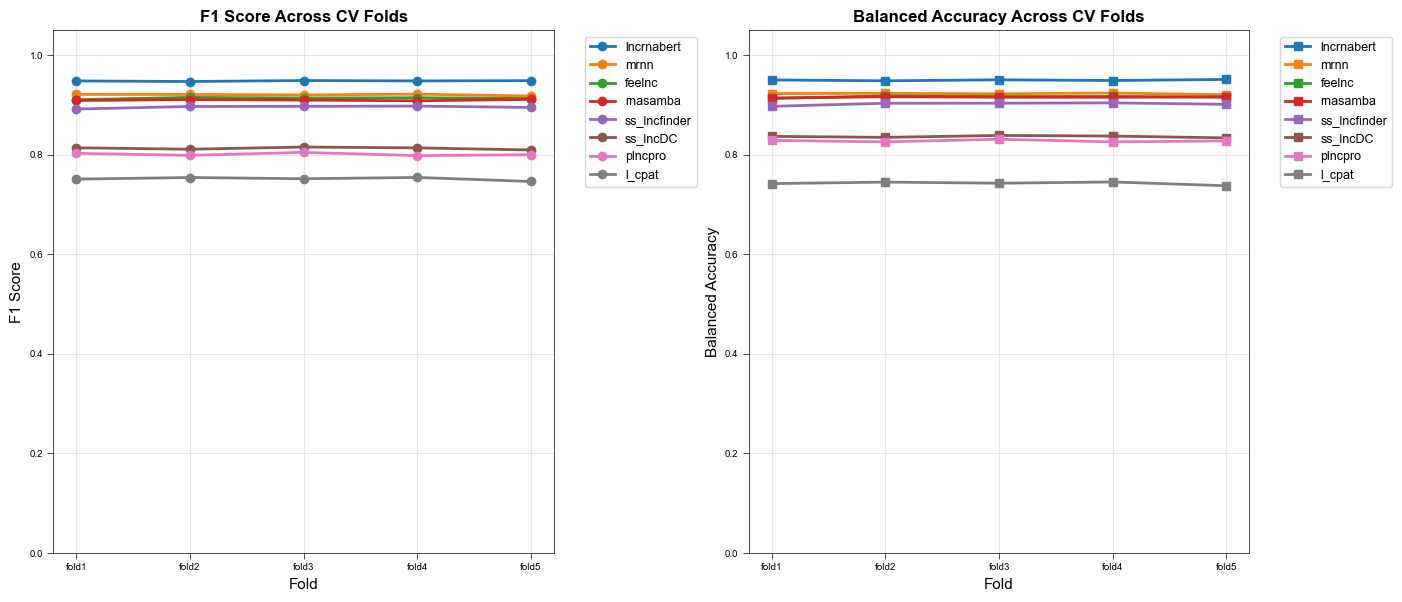

In [ ]:
# Plot F1 score and Balanced Accuracy across folds for each tool
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Prepare data for plotting
f1_data = all_fold_scores["f1_score"].unstack("fold")
ba_data = all_fold_scores["balanced_accuracy"].unstack("fold")

# Sort by mean F1 score
f1_sorted = f1_data.reindex(cv_aggregated.index)
ba_sorted = ba_data.reindex(cv_aggregated.index)

# Plot F1 Score
ax = axes[0]
for idx, tool in enumerate(f1_sorted.index):
    ax.plot(f1_sorted.columns, f1_sorted.loc[tool], marker='o', label=tool, linewidth=2, markersize=6)
ax.set_xlabel("Fold", fontsize=11)
ax.set_ylabel("F1 Score", fontsize=11)
ax.set_title("F1 Score Across CV Folds", fontsize=12, fontweight="bold")
ax.grid(alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.set_ylim([0, 1.05])

# Plot Balanced Accuracy
ax = axes[1]
for idx, tool in enumerate(ba_sorted.index):
    ax.plot(ba_sorted.columns, ba_sorted.loc[tool], marker='s', label=tool, linewidth=2, markersize=6)
ax.set_xlabel("Fold", fontsize=11)
ax.set_ylabel("Balanced Accuracy", fontsize=11)
ax.set_title("Balanced Accuracy Across CV Folds", fontsize=12, fontweight="bold")
ax.grid(alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()


/tmp/ipykernel_661297/63973917.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_boxplot, labels=labels_for_boxplot, patch_artist=True)
/tmp/ipykernel_661297/63973917.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_boxplot, labels=labels_for_boxplot, patch_artist=True)
/tmp/ipykernel_661297/63973917.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_boxplot, labels=labels_for_boxplot, patch_artist=True)
/tmp/ipykernel_661297/63973917.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels

DEBUG:matplotlib.font_manager:findfont: Matching Arial:style=normal:variant=normal:weight=bold:stretch=normal:size=13.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/home/dgarcia/miniforge3/envs/lnc-datasets/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans-Bold.ttf', name='DejaVu Sans', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/home/dgarcia/miniforge3/envs/lnc-datasets/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizThreeSymBol.ttf', name='STIXSizeThreeSym', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/home/dgarcia/miniforge3/envs/lnc-datasets/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizFiveSymReg.ttf', name='STIXSizeFiveSym', style='normal', variant='normal', weight=400, stretch='normal', 

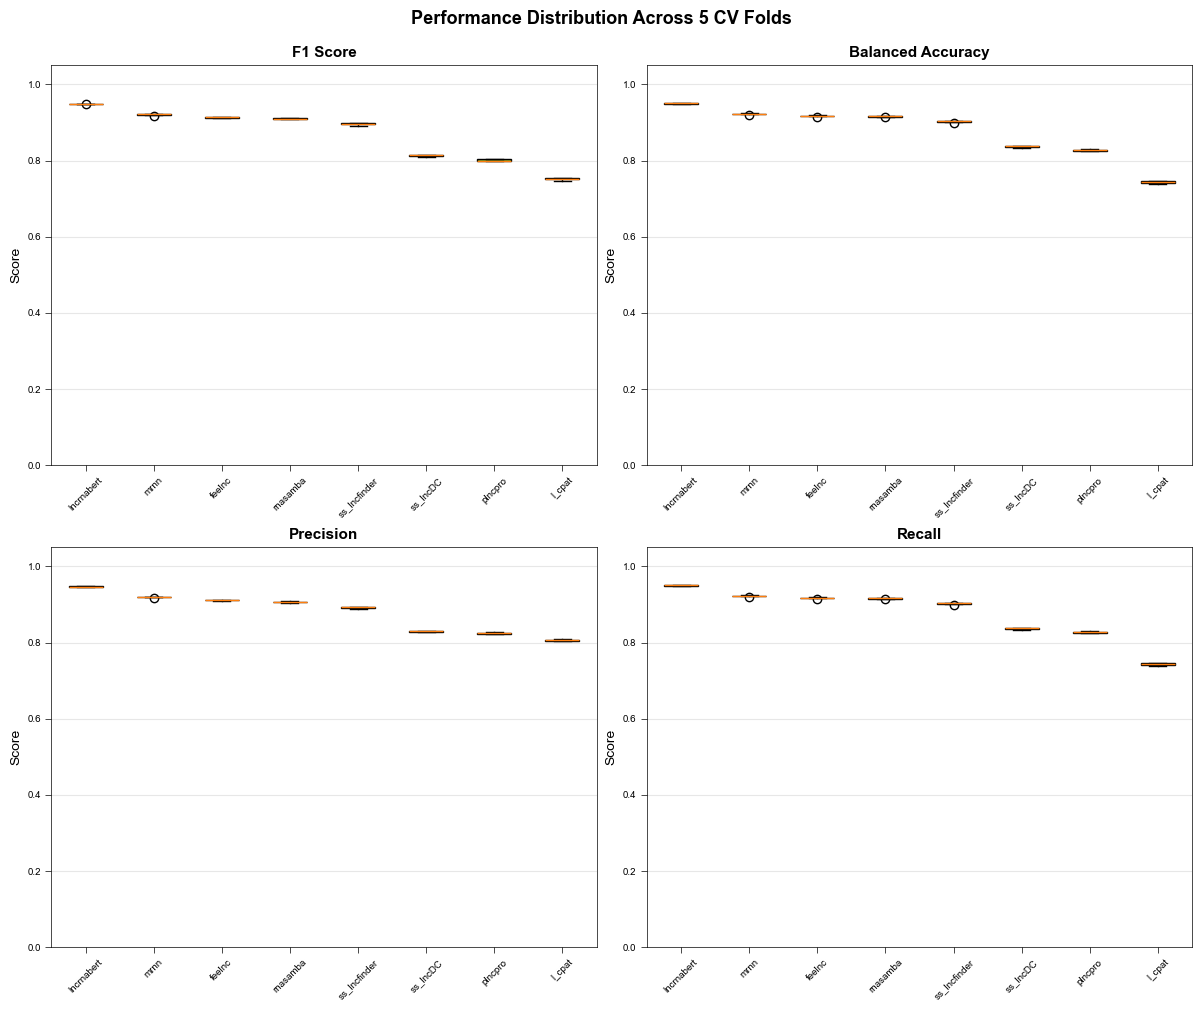

In [ ]:

# Box plots: Distribution of scores across folds
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

metrics_to_plot = [("f1_score", axes[0, 0]), 
                   ("balanced_accuracy", axes[0, 1]),
                   ("precision", axes[1, 0]), 
                   ("recall", axes[1, 1])]

for metric, ax in metrics_to_plot:
    data_for_boxplot = []
    labels_for_boxplot = []
    
    for tool in cv_aggregated.index:
        values = all_fold_scores.xs(tool, level="tool")[metric].values
        data_for_boxplot.append(values)
        labels_for_boxplot.append(tool)
    
    bp = ax.boxplot(data_for_boxplot, labels=labels_for_boxplot, patch_artist=True)
    
    # Color boxes
    colors = plt.cm.viridis(np.linspace(0, 1, len(bp['boxes'])))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    ax.set_ylabel("Score", fontsize=10)
    ax.set_title(metric.replace("_", " ").title(), fontsize=11, fontweight="bold")
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([0, 1.05])
    ax.tick_params(axis='x', rotation=45)

plt.suptitle("Performance Distribution Across 5 CV Folds", fontsize=13, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()



## Statistical Summary: Coefficient of Variation
Assess consistency/stability of tool performance across folds


In [ ]:

# Calculate Coefficient of Variation (std/mean) to assess stability
# Lower CV = more stable performance across folds
cv_stability = pd.DataFrame()

for metric in metric_cols:
    mean_col = f"{metric}_mean"
    std_col = f"{metric}_std"
    cv_stability[f"{metric}_cv"] = cv_aggregated[std_col] / cv_aggregated[mean_col]

cv_stability = cv_stability.sort_values("f1_score_cv", ascending=True)

print("="*80)
print("STABILITY METRICS: Coefficient of Variation (lower = more stable)")
print("="*80)
print(cv_stability.applymap(lambda x: f"{x:.4f}"))
print()
print("Summary statistics:")
print(cv_stability.describe())


STABILITY METRICS: Coefficient of Variation (lower = more stable)
             accuracy_cv balanced_accuracy_cv precision_cv recall_cv  \
tool                                                                   
lncrnabert        0.0008               0.0011       0.0008    0.0011   
rnasamba          0.0014               0.0011       0.0014    0.0011   
mrnn              0.0016               0.0014       0.0018    0.0014   
feelnc            0.0018               0.0022       0.0018    0.0022   
ss_lncfinder      0.0026               0.0031       0.0027    0.0031   
ss_lncDC          0.0030               0.0024       0.0020    0.0024   
plncpro           0.0035               0.0027       0.0019    0.0027   
l_cpat            0.0032               0.0042       0.0030    0.0042   

             f1_score_cv  
tool                      
lncrnabert        0.0008  
rnasamba          0.0013  
mrnn              0.0016  
feelnc            0.0020  
ss_lncfinder      0.0027  
ss_lncDC          0.0030

/tmp/ipykernel_661297/821359695.py:15: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(cv_stability.applymap(lambda x: f"{x:.4f}"))



## Summary Table: CV Performance with Confidence Intervals


In [ ]:

# Create comprehensive summary table with ranking
summary_table = cv_aggregated.copy()
summary_table["rank_by_f1"] = summary_table["f1_score_mean"].rank(ascending=False).astype(int)

# Reorder columns for readability
col_order = ["rank_by_f1", "f1_score_mean", "f1_score_std", 
             "balanced_accuracy_mean", "balanced_accuracy_std",
             "precision_mean", "precision_std",
             "recall_mean", "recall_std",
             "accuracy_mean", "accuracy_std"]
summary_table = summary_table[col_order]

print("="*120)
print("CROSS-VALIDATION PERFORMANCE SUMMARY (5 folds)")
print("="*120)
print(summary_table.to_string())
print()

# Create formatted version for export
summary_formatted = summary_table.copy()
for col in summary_formatted.columns:
    if col != "rank_by_f1":
        summary_formatted[col] = summary_formatted[col].apply(lambda x: f"{x:.4f}")

summary_formatted.to_csv(cv_output_dir / "cv_summary_table.tsv", sep="\t")
print(f"Saved summary table to: {cv_output_dir / 'cv_summary_table.tsv'}")


CROSS-VALIDATION PERFORMANCE SUMMARY (5 folds)
              rank_by_f1 f1_score_mean  f1_score_std balanced_accuracy_mean  balanced_accuracy_std precision_mean  precision_std recall_mean  recall_std accuracy_mean  accuracy_std
tool                                                                                                                                                                                
lncrnabert             1      0.948406      0.000760               0.950002               0.001091       0.946999       0.000784    0.950002    0.001091      0.950077      0.000721
mrnn                   2      0.920506      0.001484               0.922726               0.001274       0.918654       0.001657    0.922726    0.001274      0.922957      0.001475
feelnc                 3      0.913531      0.001787               0.916321               0.002008       0.911323       0.001663    0.916321    0.002008      0.916088      0.001691
rnasamba               4      0.909925      0.00


## Per-Fold Detailed Results
Individual performance for each fold


In [ ]:

# Save detailed per-fold results
for fold_name, scores in cv_scores.items():
    output_file = cv_output_dir / f"{fold_name}_performance.tsv"
    scores.to_csv(output_file, sep="\t")
    print(f"Saved {fold_name} results to: {output_file}")

print("\n" + "="*80)
print("PER-FOLD RESULTS")
print("="*80)

# Display each fold's results
for fold_name, scores in cv_scores.items():
    print(f"\n{fold_name}:")
    print(scores.sort_values("f1_score", ascending=False))


Saved fold1 results to: /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/testing/aggregated/fold1_performance.tsv
Saved fold2 results to: /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/testing/aggregated/fold2_performance.tsv
Saved fold3 results to: /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/testing/aggregated/fold3_performance.tsv
Saved fold4 results to: /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/testing/aggregated/fold4_performance.tsv
Saved fold5 results to: /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/testing/aggregated/fold5_performance.tsv

PER-FOLD RESULTS

fold1:
              accuracy balanced_accuracy precision    recall  f1_score
lncrnabert    0.950013          0.950291  0.946695  0.950291   0.94837
mrnn          0.923834          0.922936  0.919859  0.922936    0.9213
feelnc        0.913452            0.9131  0.908777    0.9131  0.910727
rnasamba      0.911349          0.914055


## Summary Visualization: Ranked Performance Table


DEBUG:matplotlib.font_manager:findfont: Matching Arial:style=normal:variant=normal:weight=bold:stretch=normal:size=10.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/home/dgarcia/miniforge3/envs/lnc-datasets/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans-Bold.ttf', name='DejaVu Sans', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/home/dgarcia/miniforge3/envs/lnc-datasets/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizThreeSymBol.ttf', name='STIXSizeThreeSym', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/home/dgarcia/miniforge3/envs/lnc-datasets/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizFiveSymReg.ttf', name='STIXSizeFiveSym', style='normal', variant='normal', weight=400, stretch='normal', 

DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/home/dgarcia/.local/share/fonts/Arialbi.TTF', name='Arial', style='italic', variant='normal', weight=700, stretch='normal', size='scalable')) = 1.05



FINAL CV RANKINGS - Top Performers
              Rank  F1 Score Bal. Accuracy Precision    Recall  Accuracy
tool                                                                    
lncrnabert       1  0.948406      0.950002  0.946999  0.950002  0.950077
mrnn             2  0.920506      0.922726  0.918654  0.922726  0.922957
feelnc           3  0.913531      0.916321  0.911323  0.916321  0.916088
rnasamba         4  0.909925      0.915639  0.906623  0.915639  0.912066
ss_lncfinder     5  0.895828      0.902037  0.892528  0.902037  0.898175
ss_lncDC         6  0.812868      0.836505   0.82929  0.836505  0.813088
plncpro          7  0.801034      0.827958  0.824637  0.827958  0.801078
l_cpat           8  0.751637      0.742676  0.806382  0.742676  0.779932

Note: All values are aggregated means across 5 CV folds



DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/home/dgarcia/.local/share/fonts/Timesbi.TTF', name='Times New Roman', style='italic', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/home/dgarcia/.local/share/fonts/Trebucit.TTF', name='Trebuchet MS', style='italic', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/home/dgarcia/.local/share/fonts/Comicbd.TTF', name='Comic Sans MS', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/home/dgarcia/.local/share/fonts/Georgia.TTF', name='Georgia', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/home/dgarcia/.local/share/fonts/Verdana.TTF', name

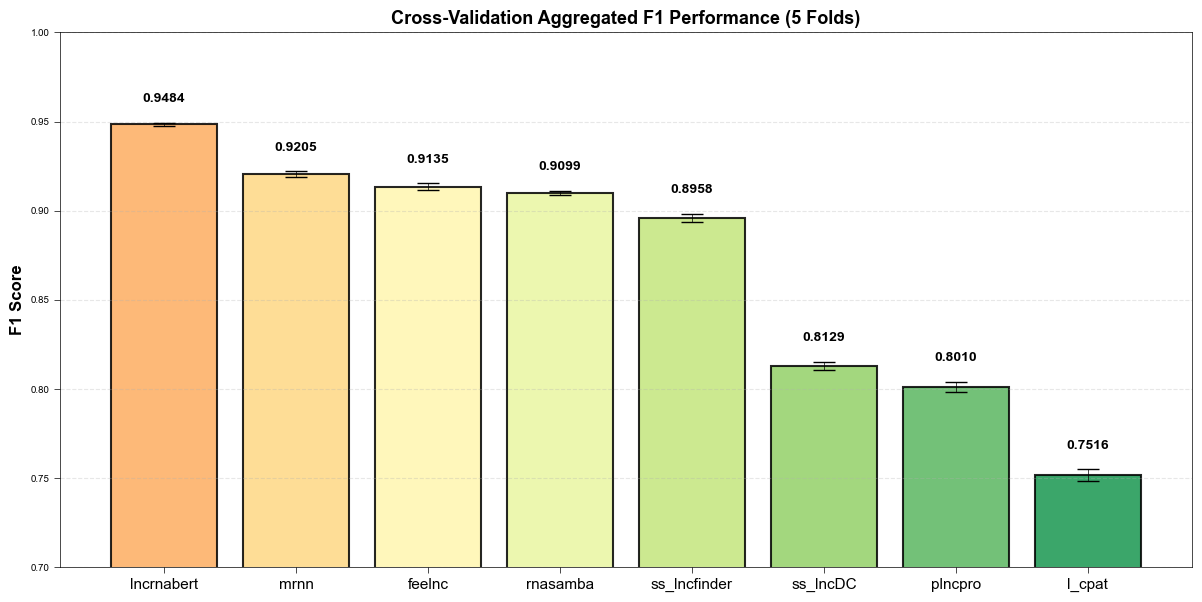


✓ CV analysis complete! All results saved to:
  → /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/testing/aggregated


In [ ]:

# Create a visual representation of aggregated performance
display_summary = summary_table[["rank_by_f1", "f1_score_mean", "balanced_accuracy_mean", 
                                  "precision_mean", "recall_mean", "accuracy_mean"]].copy()
display_summary.columns = ["Rank", "F1 Score", "Bal. Accuracy", "Precision", "Recall", "Accuracy"]

print("\n" + "="*100)
print("FINAL CV RANKINGS - Top Performers")
print("="*100)
print(display_summary.to_string())
print("\nNote: All values are aggregated means across 5 CV folds")
print("="*100 + "\n")

# Create bar chart comparing F1 scores with error bars
fig, ax = plt.subplots(figsize=(12, 6))

tools = summary_table.index
f1_means = summary_table["f1_score_mean"]
f1_stds = summary_table["f1_score_std"]

x_pos = np.arange(len(tools))
colors_ranked = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(tools)))

bars = ax.bar(x_pos, f1_means, yerr=f1_stds, capsize=8, 
              color=colors_ranked, alpha=0.85, edgecolor="black", linewidth=1.5)

# Add value labels on bars
for i, (tool, val, std) in enumerate(zip(tools, f1_means, f1_stds)):
    ax.text(i, val + std + 0.01, f"{val:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_xticks(x_pos)
ax.set_xticklabels(tools, fontsize=11)
ax.set_ylabel("F1 Score", fontsize=12, fontweight="bold")
ax.set_title("Cross-Validation Aggregated F1 Performance (5 Folds)", fontsize=13, fontweight="bold")
ax.set_ylim([0.7, 1.0])
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.axhline(y=0.5, color="red", linestyle=":", alpha=0.3, linewidth=1)

plt.tight_layout()
plt.show()

print("\n✓ CV analysis complete! All results saved to:")
print(f"  → {cv_output_dir}")


/tmp/ipykernel_661297/3877915027.py:35: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


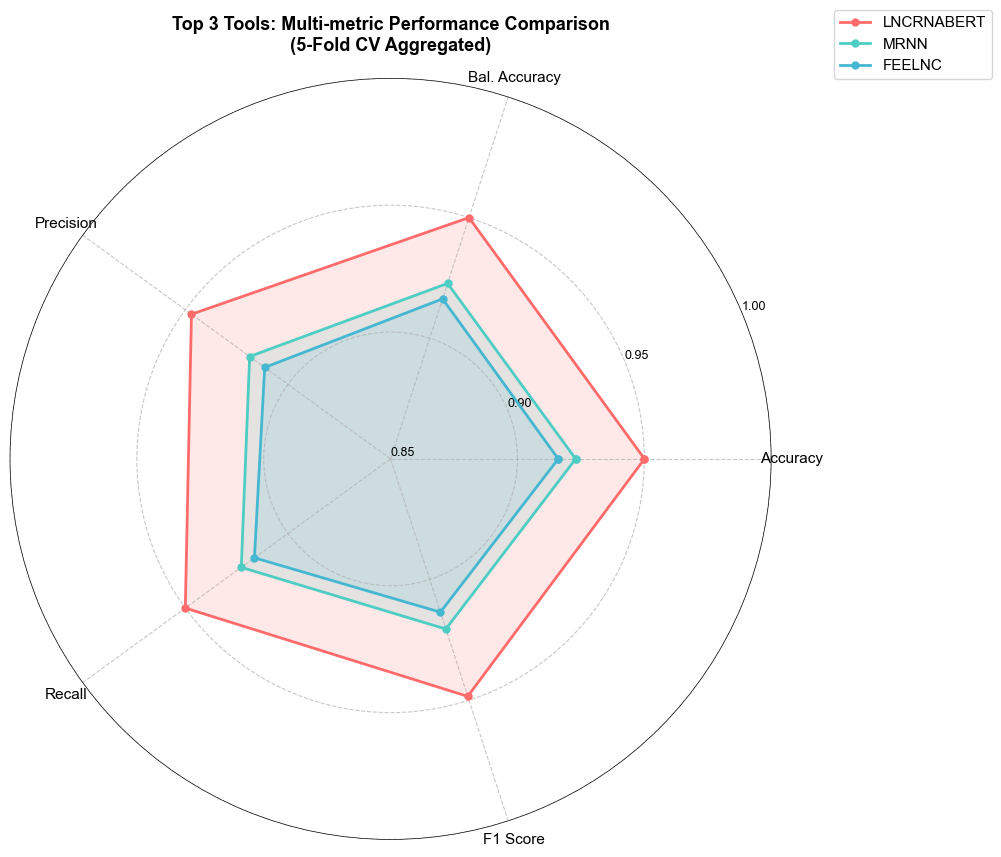


Analysis Summary:
✓ Evaluated 5 folds with 8 tools
✓ Total test instances: 111,652
✓ Best performer: lncrnabert (F1 = 0.9484)
✓ 3-tool ensemble F1 potential: ~0.9275


In [ ]:

# Radar chart comparing top 3 tools
from math import pi

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

# Select top 3 tools
top_tools = summary_table.head(3).index.tolist()
metrics_to_plot = ["accuracy_mean", "balanced_accuracy_mean", "precision_mean", "recall_mean", "f1_score_mean"]
metric_labels = ["Accuracy", "Bal. Accuracy", "Precision", "Recall", "F1 Score"]

num_vars = len(metrics_to_plot)
angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
angles += angles[:1]

colors_top = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for idx, tool in enumerate(top_tools):
    values = summary_table.loc[tool, metrics_to_plot].tolist()
    values += values[:1]
    
    ax.plot(angles, values, 'o-', linewidth=2, label=tool.upper(), color=colors_top[idx])
    ax.fill(angles, values, alpha=0.15, color=colors_top[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylim(0.85, 1.0)
ax.set_yticks([0.85, 0.90, 0.95, 1.00])
ax.set_yticklabels(['0.85', '0.90', '0.95', '1.00'], fontsize=9)
ax.grid(True, linestyle='--', alpha=0.7)

plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
plt.title('Top 3 Tools: Multi-metric Performance Comparison\n(5-Fold CV Aggregated)', 
          fontsize=13, fontweight="bold", pad=20)

plt.tight_layout()
plt.show()

print("\nAnalysis Summary:")
print(f"✓ Evaluated {len(cv_scores)} folds with {len(summary_table)} tools")
print(f"✓ Total test instances: {sum([len(df) for df in cv_binary_dfs.values()]):,}")
print(f"✓ Best performer: {summary_table.index[0]} (F1 = {summary_table.iloc[0]['f1_score_mean']:.4f})")
print(f"✓ 3-tool ensemble F1 potential: ~{(summary_table.iloc[0]['f1_score_mean'] + summary_table.iloc[1]['f1_score_mean'] + summary_table.iloc[2]['f1_score_mean']) / 3:.4f}")


In [ ]:
# Tool names
tool_names = {'lncrnabert': "lncRNABERT",
 'mrnn': "mRNN",
 'feelnc': "FEELnc",
 'rnasamba': "RNAsamba",
 'ss_lncfinder': "LncFinder",
 'ss_lncDC': "LncDC",
 'plncpro': "PlncPro",
 'l_cpat': "CPAT"
}

cv_aggregated.index = cv_aggregated.index.map(tool_names)

/tmp/ipykernel_661297/2063966.py:8: UserWarning: The Figure parameters 'layout' and 'constrained_layout' cannot be used together. Please use 'layout' only.
  fig, axes_map = plt.subplot_mosaic(layout,
DEBUG:matplotlib.backends.backend_pdf:Assigning font /F1 = '/home/dgarcia/.local/share/fonts/Arial.TTF'
DEBUG:matplotlib.backends.backend_pdf:Embedding font /home/dgarcia/.local/share/fonts/Arial.TTF.
DEBUG:matplotlib.backends.backend_pdf:Writing TrueType font.
DEBUG:matplotlib.backends.backend_pdf:SUBSET /home/dgarcia/.local/share/fonts/Arial.TTF characters:  .01257ABCDEFLNPRSTabcdeilmnorsuy
DEBUG:fontTools.subset.timer:Took 0.001s to load font
DEBUG:fontTools.ttLib.ttFont:Reading 'maxp' table from disk
DEBUG:fontTools.ttLib.ttFont:Decompiling 'maxp' table
DEBUG:fontTools.subset.timer:Took 0.001s to load 'maxp'
DEBUG:fontTools.subset.timer:Took 0.000s to prune 'maxp'
INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
DEBUG:fontTools.ttLib.ttFont:Reading 'cmap' table fro

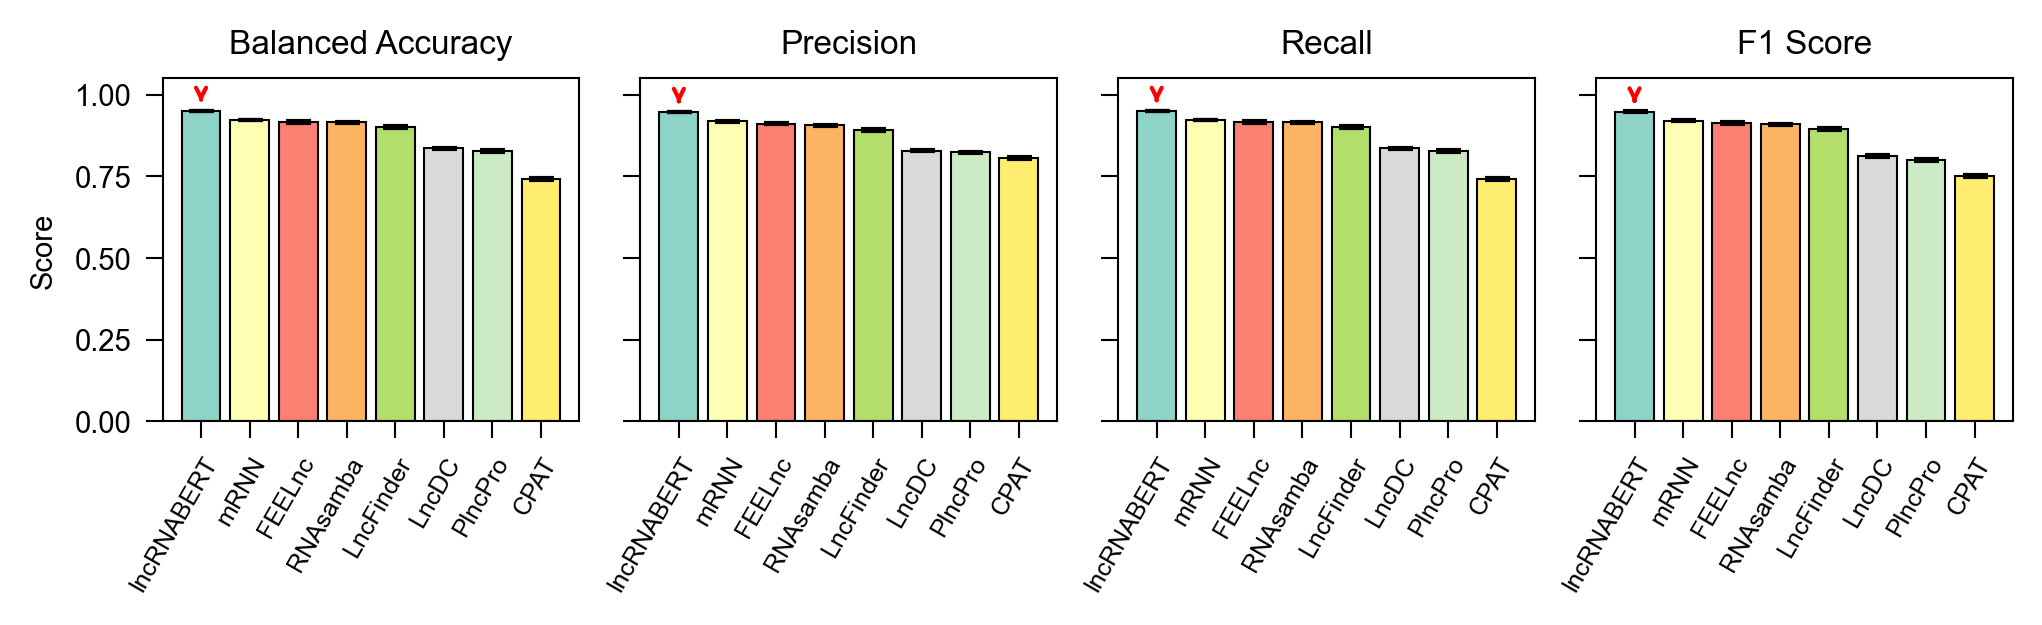

In [ ]:
# Visualize CV aggregated performance with multi-panel layout
layout = [
    ["balanced_accuracy", "precision", "recall", "f1_score"],
]
fig_h_cm = 5
fig_w_cm = 17

fig, axes_map = plt.subplot_mosaic(layout,
                                   figsize=(fig_w_cm/2.54, fig_h_cm/2.54),
                                   constrained_layout=True,
                                   dpi=300,
                                   layout="constrained")

metrics = ["accuracy", "balanced_accuracy", "precision", "recall", "f1_score"]
n_tools = len(cv_aggregated)

colors = plt.cm.Set3(np.linspace(0, 1, n_tools))


for n_plot, metric in enumerate(metrics):
    if metric not in [item for sublist in layout for item in sublist]:
        continue
    ax = axes_map[metric]
    mean_col = f"{metric}_mean"
    std_col = f"{metric}_std"

    x_pos = np.arange(n_tools)
    bars = ax.bar(
        x_pos,
        cv_aggregated[mean_col],
        yerr=cv_aggregated[std_col],
        capsize=3,
        alpha=1,
        color=colors,
        edgecolor="black",
        linewidth=0.5,
    )

    # x-axis
    ax.set_xticks(x_pos)
    ax.set_xticklabels(cv_aggregated.index, rotation=60, ha="right", fontsize=6)
    
    # Shift x-tick labels slightly to the right
    dx = 0.07
    offset = transforms.ScaledTranslation(dx, 0, fig.dpi_scale_trans)
    for label in ax.get_xticklabels():
        label.set_transform(label.get_transform() + offset)
    
    # y-axis
    ax.set_ylim([0, 1.05])
    ax.set_ylabel("Score", fontsize=7)
    ax.tick_params(axis='y', labelsize=7)
    ax.label_outer()

    # Title
    ax.set_title(metric.replace("_", " ").title(), fontsize=8)

    # Annotate best performer with arrow
    top_idx = np.argmax(cv_aggregated[mean_col].to_numpy())
    top_bar = bars[top_idx]
    center_x = top_bar.get_x() + top_bar.get_width() / 2
    yerr_val = float(cv_aggregated[std_col].iloc[top_idx])
    top_y = top_bar.get_height() + yerr_val
    ax.annotate(
        "",
        xy=(center_x, top_y),
        xytext=(center_x, top_y + 0.06),
        arrowprops=dict(arrowstyle="->", color="red", lw=1),
        clip_on=False,
    )

DATASET = "gencode.v47.common.cdhit.cv"
FIGURE_DIR = f"/mnt/cbib/LNClassifier/paper/results/{DATASET}/figures"
os.makedirs(FIGURE_DIR, exist_ok=True)
#plt.savefig(os.path.join(FIGURE_DIR, "performance_CV.pdf"), dpi=300, format='pdf')

plt.show()
